## 1. Import Libraries


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## 2. Load Dataset

In [4]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Convert TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Remove missing values
df = df.dropna()

# Remove customerID
df = df.drop("customerID", axis=1)

# Encode categorical columns
df = pd.get_dummies(df, drop_first=True)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


## 3. Stage 1: Data Understanding

Shape: (7032, 31)
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7032 non-null   bool   
 5   Partner_Yes                            7032 non-null   bool   
 6   Dependents_Yes                         7032 non-null   bool   
 7   PhoneService_Yes                       7032 non-null   bool   
 8   MultipleLines_No phone service         7032 non-null   bool   
 9   MultipleLines_Yes                      7032 non-null   bool   
 10  InternetService_Fiber optic            7032 non-null   bool   
 11  In

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Churn_Yes
False    5163
True     1869
Name: count, dtype: int64


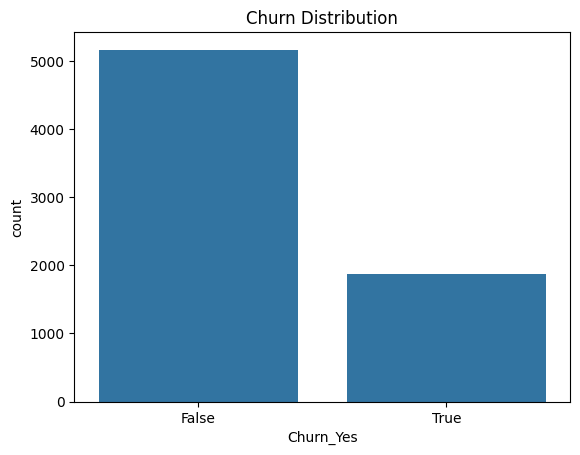

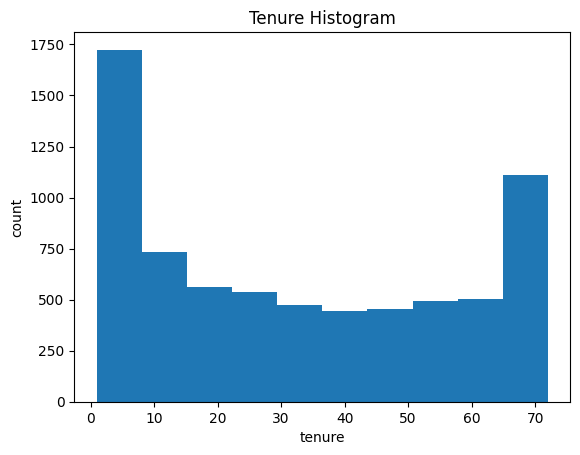

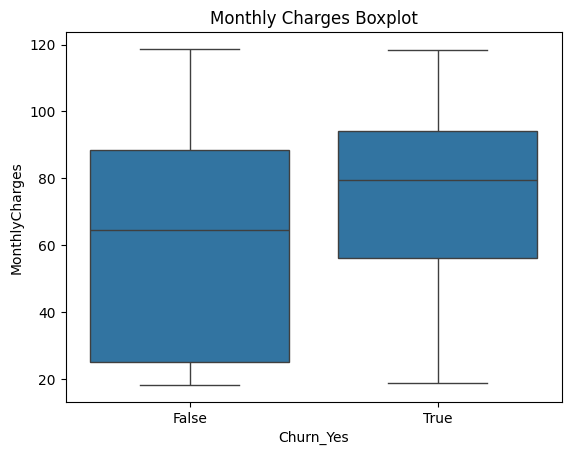

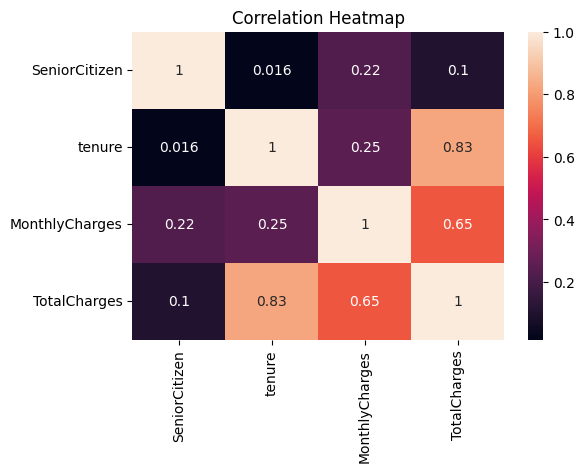

In [12]:
# Basic information
print("Shape:", df.shape)

df.info()

display(df.describe())

print(df["Churn_Yes"].value_counts())

# Churn Distribution
sns.countplot(data=df, x="Churn_Yes")
plt.title("Churn Distribution")
plt.show()

# Tenure Histogram
plt.hist(df["tenure"], bins=10)
plt.title("Tenure Histogram")
plt.xlabel("tenure")
plt.ylabel("count")
plt.show()

# Monthly Charges Boxplot
sns.boxplot(data=df, x="Churn_Yes", y="MonthlyCharges")
plt.title("Monthly Charges Boxplot")
plt.show()

# Convert TotalCharges فقط عشان نقدر نعمل correlation
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(
    df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].corr(),
    annot=True
)
plt.title("Correlation Heatmap")
plt.show()

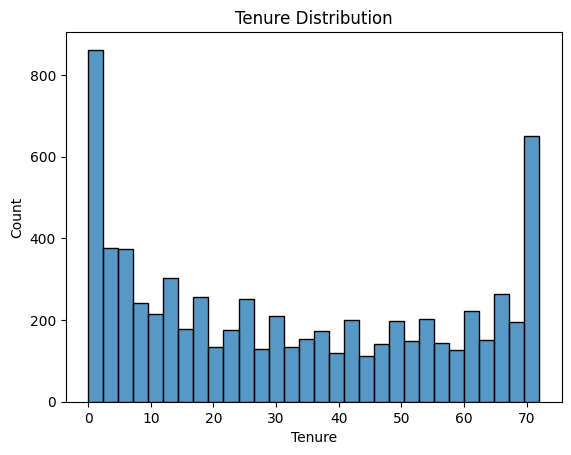

In [45]:
sns.histplot(data=df, x="tenure", bins=30)
plt.title("Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Count")
plt.show()

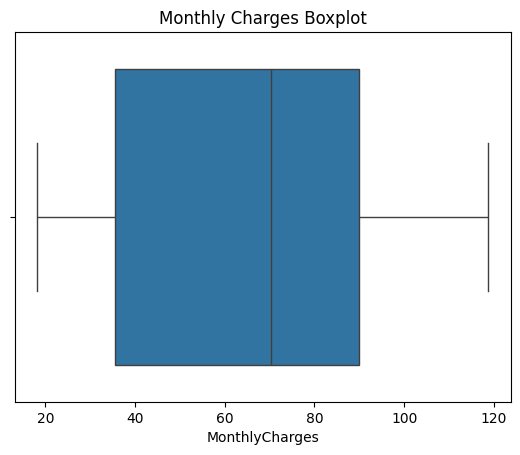

In [46]:
sns.boxplot(x=df["MonthlyCharges"])
plt.title("Monthly Charges Boxplot")
plt.show()

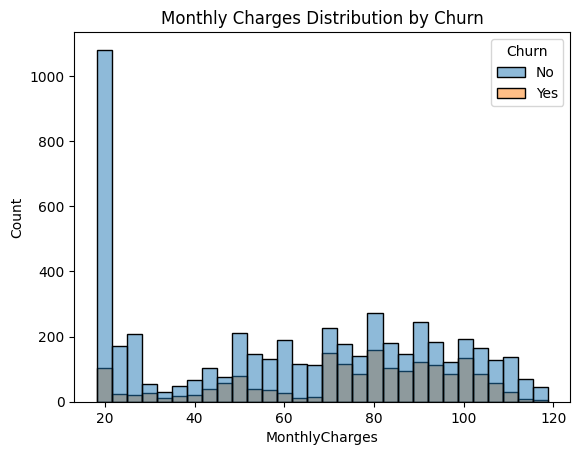

In [47]:
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", bins=30)
plt.title("Monthly Charges Distribution by Churn")
plt.show()

## Stage 4: Feature Analysis (curse of dimentinality)

tenure                                 0.441515
InternetService_Fiber optic            0.355756
TotalCharges                           0.068839
Contract_One year                      0.030415
OnlineSecurity_No internet service     0.023181
PaymentMethod_Electronic check         0.019139
MonthlyCharges                         0.016413
StreamingMovies_No internet service    0.011578
Contract_Two year                      0.009869
OnlineSecurity_Yes                     0.007843
dtype: float64


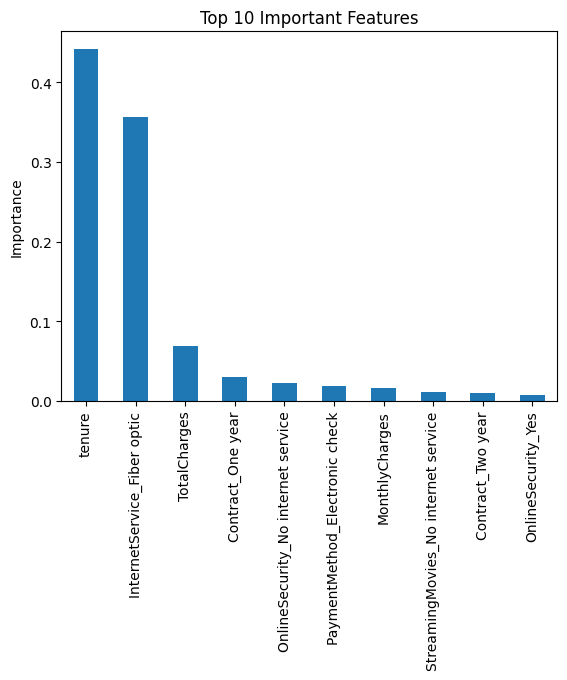

In [15]:
X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

model_dt_temp = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt_temp.fit(X_train, y_train)

importance = pd.Series(
    model_dt_temp.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(10))

importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.ylabel("Importance")
plt.show()

##  Stage 5: Classification Models

In [16]:
# Scaling for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Decision Tree
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

# SVM
model_svm = SVC()
model_svm.fit(X_train_scaled, y_train)

y_pred_svm = model_svm.predict(X_test_scaled)

# Accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Decision Tree:", accuracy_dt)
print("SVM:", accuracy_svm)

Decision Tree: 0.7781990521327015
SVM: 0.7924170616113744


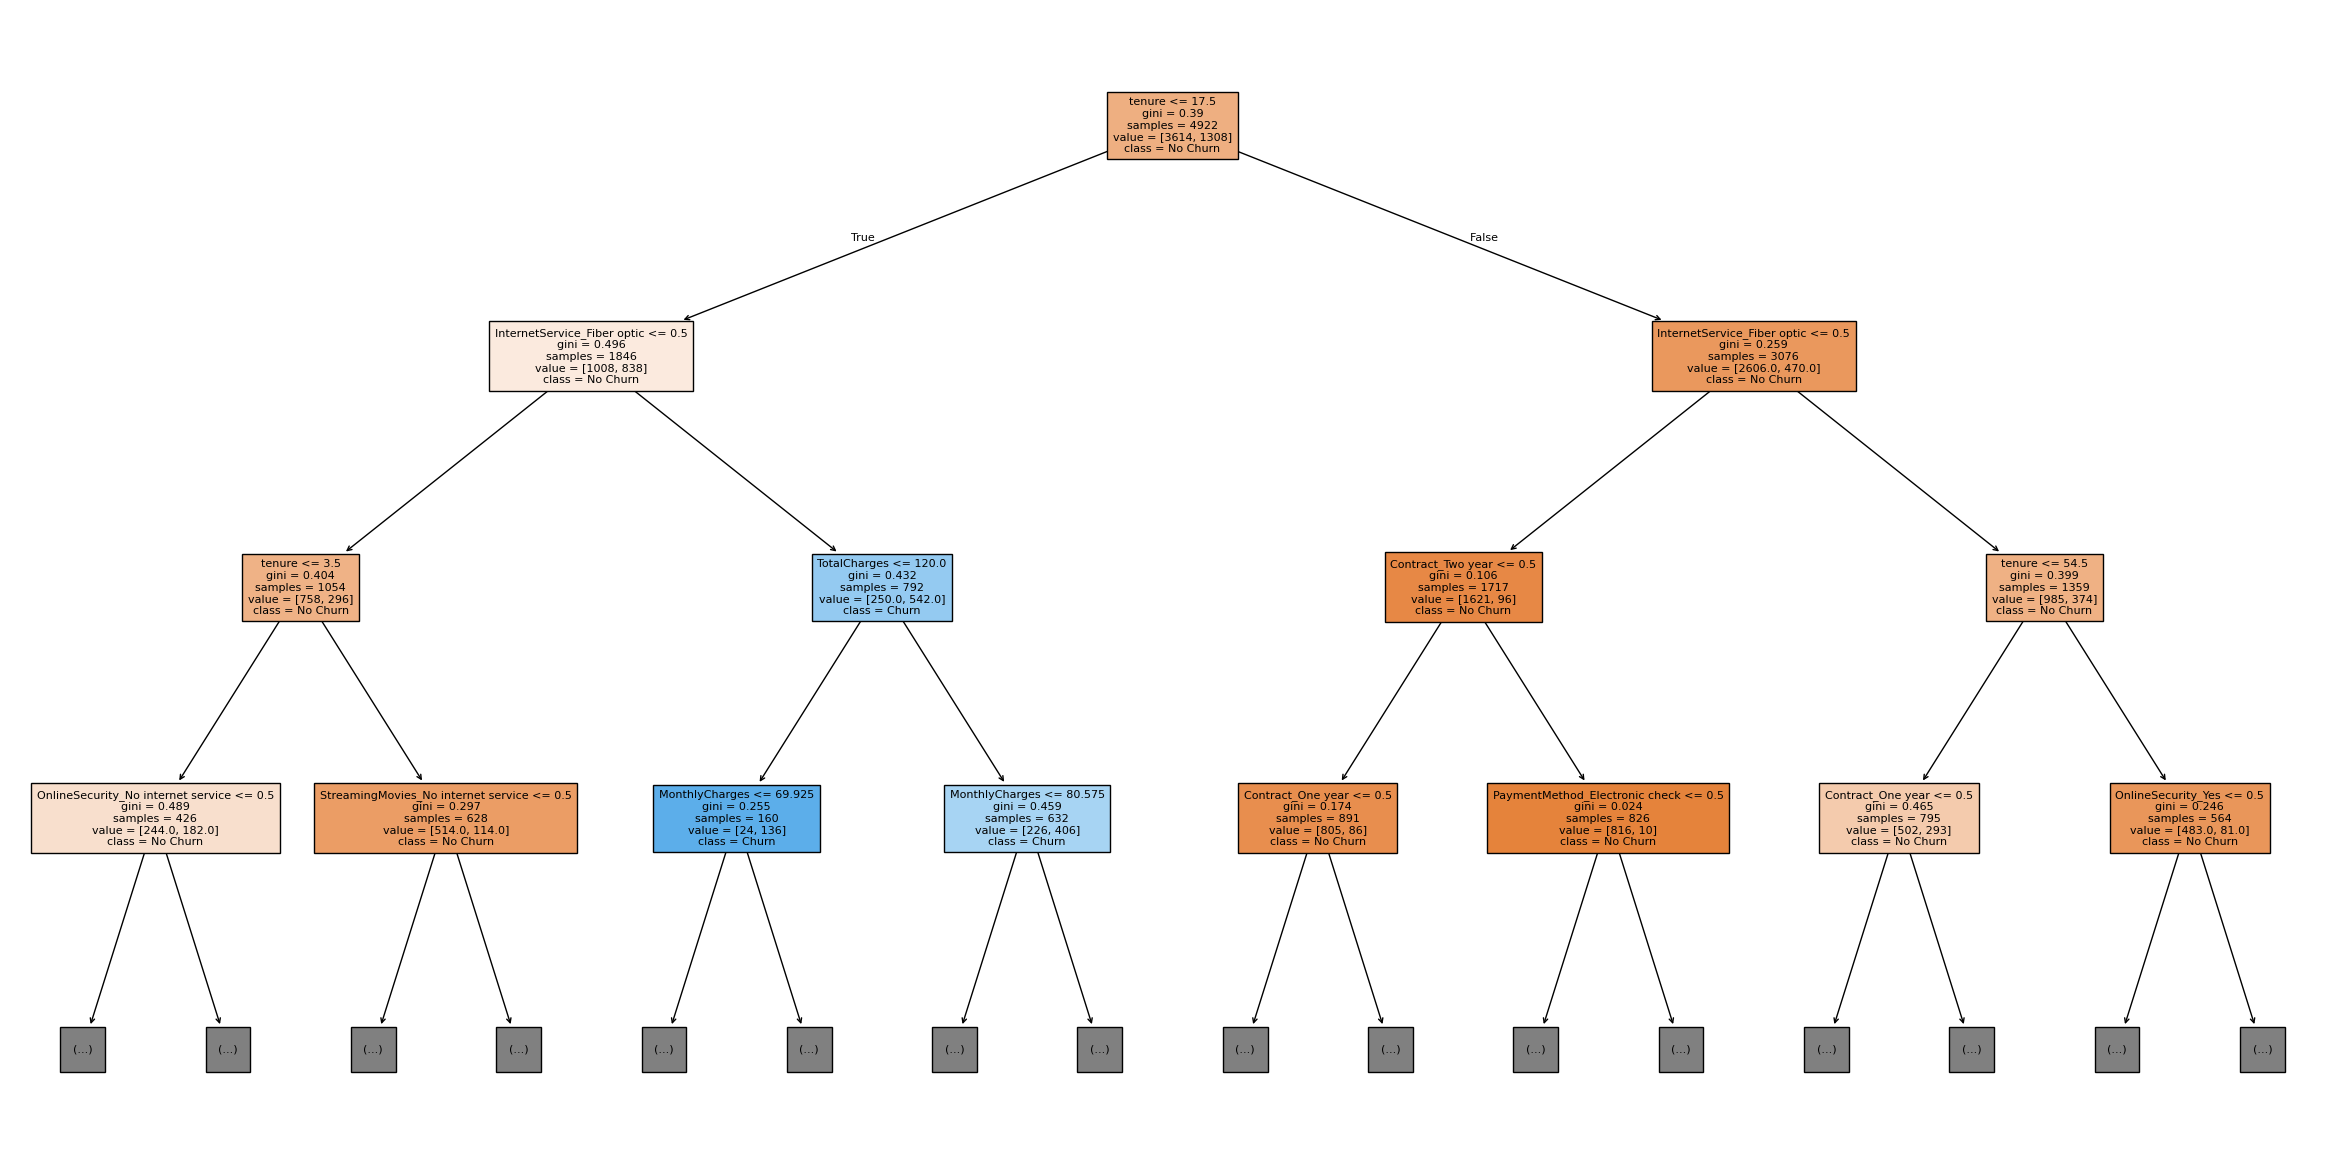

In [19]:

plt.figure(figsize=(30, 15))

plot_tree(
    model_dt,
    max_depth=3,
    filled=True,
    feature_names=list(X.columns),
    class_names=["No Churn", "Churn"],
    fontsize=8
)

plt.show()

##  Stage 6:  Model Evaluation 

Decision Tree Accuracy: 0.7781990521327015
              precision    recall  f1-score   support

       False       0.85      0.85      0.85      1549
        True       0.58      0.58      0.58       561

    accuracy                           0.78      2110
   macro avg       0.72      0.71      0.72      2110
weighted avg       0.78      0.78      0.78      2110



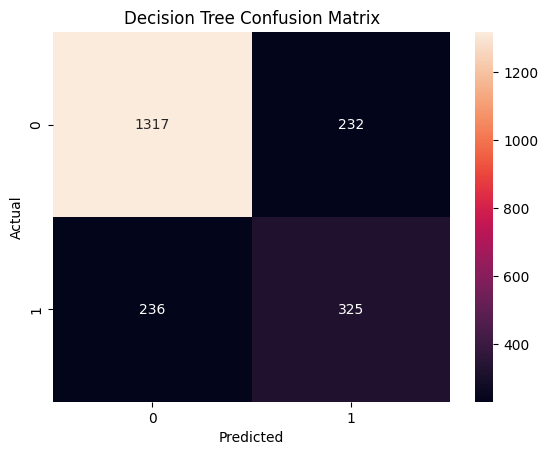

SVM Accuracy: 0.7924170616113744
              precision    recall  f1-score   support

       False       0.83      0.90      0.86      1549
        True       0.65      0.48      0.55       561

    accuracy                           0.79      2110
   macro avg       0.74      0.69      0.71      2110
weighted avg       0.78      0.79      0.78      2110



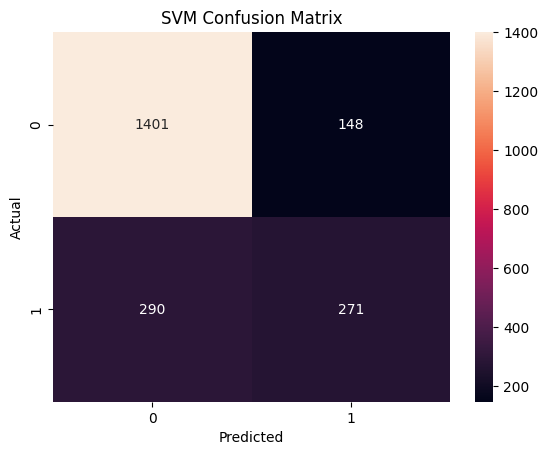

,Model,Accuracy
0,Decision Tree,0.778199
1,SVM,0.792417


In [21]:
# Decision Tree Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt="d")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SVM Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt="d")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Model Comparison Table
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_svm)
    ]
})

comparison

## 10. Conclusion

This project demonstrated the use of machine learning techniques for customer churn 
prediction in telecommunication companies. Several stages of the data mining pipeline were 
implemented successfully, including data understanding, preprocessing, feature analysis, 
classification, clustering, and model evaluation. 
Two classification algorithms were implemented and compared: Decision Tree Classifier and 
Support Vector Machine (SVM). The experimental results showed that the SVM model 
achieved the best overall performance with an accuracy of approximately 79.6%, 
outperforming the Decision Tree classifier.
K-Means clustering also revealed hidden customer groups based on customer behavior and 
billing patterns. Overall, the project demonstrated that machine learning models can 
provide valuable support for customer churn prediction and customer retention strategies.